In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pickle

In [3]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns= iris.feature_names)
y = pd.Series(iris.target, name= 'Species')

In [26]:
sample = dict(X.iloc[16])

In [27]:
y.iloc[16]

0

In [4]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int32

In [9]:
X.shape

(150, 4)

In [15]:
target_names = list(iris.target_names)
target_names

['setosa', 'versicolor', 'virginica']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print(X_train.shape)
print(X_test.shape)

(112, 4)
(38, 4)


In [22]:
model = RandomForestClassifier(
    n_estimators= 100,
)

model.fit(X_train, y_train)
model.classes_

array([0, 1, 2])

In [31]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(model, X,y, cv= 5, scoring= 'accuracy')
class_report = classification_report(y_test, y_pred, target_names = target_names)
print(f'the accuracy is {accuracy}')
print(f'the Cross Val Score is {cv_scores}')
print(f'the Class Report is {class_report}')


the accuracy is 1.0
the Cross Val Score is [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
the Class Report is               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



<Axes: >

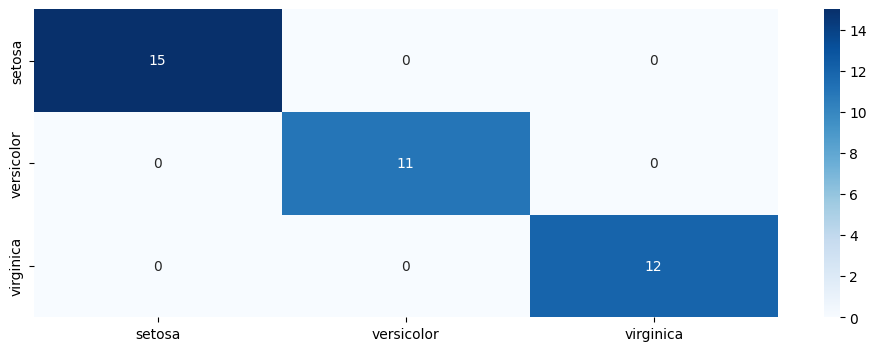

In [36]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(figsize=(12, 4))
 
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)

In [38]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)